In [2]:
import pandas as pd

df = pd.read_csv("data/retail_sales.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# RetailIQ_AI

## AI Powered Retail Sales & Customer Intelligence Platform

**Student:** Param Shelke

**Internship:** AICTE | IBM SkillsBuild Data Analytics with AI 2026

**Tools:** Python, Pandas, Plotly, Scikit-Learn

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Load Dataset

df = pd.read_csv("data/retail_sales.csv")

print("Rows & Columns:", df.shape)

df.head()

In [3]:
# Data Inspection

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [4]:
# Missing Values

df.isnull().sum()


Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [5]:
# Statistics

df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


# RetailIQ_AI

## AI Powered Retail Sales & Customer Intelligence Platform

**Student:** Param Shelke

**Internship:** AICTE | IBM SkillsBuild Data Analytics with AI 2026

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
df = pd.read_csv("data/retail_sales.csv")

print(df.shape)

df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [11]:

# Create a clean copy of the retail sales dataset
df = df.drop_duplicates().copy()

# Remove records without a Customer ID
df = df.dropna(subset=["Customer ID"])

# Remove negative quantities and prices
df = df[(df["Quantity"] >= 0) & (df["Price"] >= 0)]

# Convert invoice dates to datetime and remove invalid dates
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df = df.dropna(subset=["InvoiceDate"])

# Calculate total revenue for each transaction
df["Revenue"] = df["Quantity"] * df["Price"]

# Extract date and time components
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour

# Reset the index after cleaning
df.reset_index(drop=True, inplace=True)

df


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,2009,12,1,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009,12,1,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009,12,1,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80,2009,12,1,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,2009,12,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
779490,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12,9,12
779491,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12
779492,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,9,12
779493,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85,2011,12,9,12


In [12]:

import plotly.graph_objects as go
from plotly.subplots import make_subplots

total_revenue = df["Revenue"].sum()
total_orders = df["Invoice"].nunique()
total_customers = df["Customer ID"].nunique()
average_order_value = total_revenue / total_orders

fig = make_subplots(
    rows=1,
    cols=4,
    specs=[[{"type": "indicator"}] * 4]
)

kpis = [
    ("Total Revenue", total_revenue, "$,.2f"),
    ("Total Orders", total_orders, ","),
    ("Total Customers", total_customers, ","),
    ("Average Order Value", average_order_value, "$,.2f")
]

for index, (title, value, number_format) in enumerate(kpis, start=1):
    fig.add_trace(
        go.Indicator(
            mode="number",
            value=value,
            title={"text": title},
            number={"valueformat": number_format}
        ),
        row=1,
        col=index
    )

fig.update_layout(
    title="Retail Sales KPI Dashboard",
    height=300,
    width=1200
)

fig.show()


In [14]:
monthly_revenue = (
    df.set_index("InvoiceDate")
      .resample("ME")["Revenue"]
      .sum()
      .reset_index()
)

fig_monthly_revenue = px.line(
    monthly_revenue,
    x="InvoiceDate",
    y="Revenue",
    markers=True,
    title="Monthly Revenue Trend",
    labels={
        "InvoiceDate": "Month",
        "Revenue": "Revenue ($)"
    },
    template="plotly_dark"
)

fig_monthly_revenue.update_traces(
    line=dict(color="#00CC96", width=3),
    marker=dict(size=8),
    hovertemplate="Month: %{x|%b %Y}<br>Revenue: $%{y:,.2f}<extra></extra>"
)

fig_monthly_revenue.update_layout(
    height=550,
    title_x=0.5,
    hovermode="x unified",
    xaxis=dict(
        title="Month",
        tickformat="%b %Y",
        tickangle=-45
    ),
    yaxis=dict(
        title="Revenue ($)",
        tickformat="$,.0f"
    )
)

fig_monthly_revenue.show()

In [15]:
top_products = (
    df.assign(Description=df["Description"].fillna("Unknown"))
      .groupby("Description", as_index=False)["Revenue"]
      .sum()
      .sort_values("Revenue", ascending=False)
      .head(10)
)

fig_top_products = px.bar(
    top_products,
    x="Revenue",
    y="Description",
    orientation="h",
    text="Revenue",
    title="Top 10 Products by Total Revenue",
    labels={"Revenue": "Total Revenue ($)", "Description": "Product"},
    template="plotly_dark"
)

fig_top_products.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside"
)

fig_top_products.update_layout(
    height=600,
    title_x=0.5,
    yaxis={"autorange": "reversed"},
    xaxis_tickformat="$,.0f"
)

fig_top_products.show()

In [16]:
top_countries = (
    df.groupby("Country", as_index=False)["Revenue"]
      .sum()
      .sort_values("Revenue", ascending=False)
      .head(10)
)

fig_top_countries = px.bar(
    top_countries,
    x="Revenue",
    y="Country",
    orientation="h",
    text="Revenue",
    title="Top 10 Countries by Revenue",
    labels={"Revenue": "Total Revenue ($)", "Country": "Country"},
    template="plotly_dark"
)

fig_top_countries.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside"
)

fig_top_countries.update_layout(
    height=550,
    title_x=0.5,
    yaxis={"autorange": "reversed"},
    xaxis_tickformat="$,.0f"
)

fig_top_countries.show()

In [17]:
# RFM Customer Segmentation

reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("Customer ID")
      .agg(
          Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
          Frequency=("Invoice", "nunique"),
          Monetary=("Revenue", "sum")
      )
      .reset_index()
)

# Quartile-based RFM scores
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"), 4, labels=[4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]
).astype(int)

rfm["RFM_Score"] = rfm[["R_Score", "F_Score", "M_Score"]].sum(axis=1)

def classify_customer(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champion"
    elif row["R_Score"] >= 3 and row["F_Score"] >= 3 and row["M_Score"] >= 3:
        return "Loyal"
    elif row["R_Score"] <= 2 and (row["F_Score"] >= 3 or row["M_Score"] >= 3):
        return "At Risk"
    return "Regular"

rfm["Segment"] = rfm.apply(classify_customer, axis=1)

# Segment distribution
segment_distribution = (
    rfm["Segment"]
    .value_counts()
    .rename_axis("Segment")
    .reset_index(name="Customers")
)

segment_distribution["Percentage"] = (
    segment_distribution["Customers"] / len(rfm) * 100
)

fig_rfm_segments = px.bar(
    segment_distribution,
    x="Segment",
    y="Customers",
    color="Segment",
    text="Customers",
    title="RFM Customer Segment Distribution",
    labels={"Customers": "Number of Customers"},
    color_discrete_map={
        "Champion": "#00CC96",
        "Loyal": "#636EFA",
        "Regular": "#FFA15A",
        "At Risk": "#EF553B"
    },
    template="plotly_dark"
)

fig_rfm_segments.update_traces(
    texttemplate="%{text}",
    textposition="outside"
)

fig_rfm_segments.update_layout(
    title_x=0.5,
    showlegend=False,
    yaxis=dict(title="Number of Customers")
)

fig_rfm_segments.show()

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,12,77556.46,2,4,4,10,At Risk
1,12347.0,2,8,4921.53,4,4,4,12,Champion
2,12348.0,75,5,2019.40,3,3,3,9,Loyal
3,12349.0,19,4,4428.69,4,3,4,11,Loyal
4,12350.0,310,1,334.40,2,1,1,4,Regular


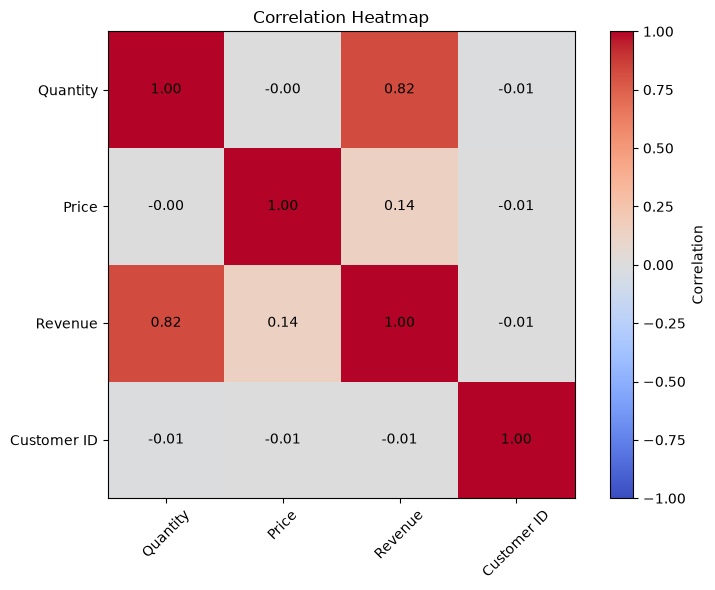

In [18]:
correlation_data = df[["Quantity", "Price", "Revenue", "Customer ID"]]
correlation_matrix = correlation_data.corr()

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Accuracy: 0.9997

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00     51534
         Low       1.00      1.00      1.00     52049
      Medium       1.00      1.00      1.00     52316

    accuracy                           1.00    155899
   macro avg       1.00      1.00      1.00    155899
weighted avg       1.00      1.00      1.00    155899



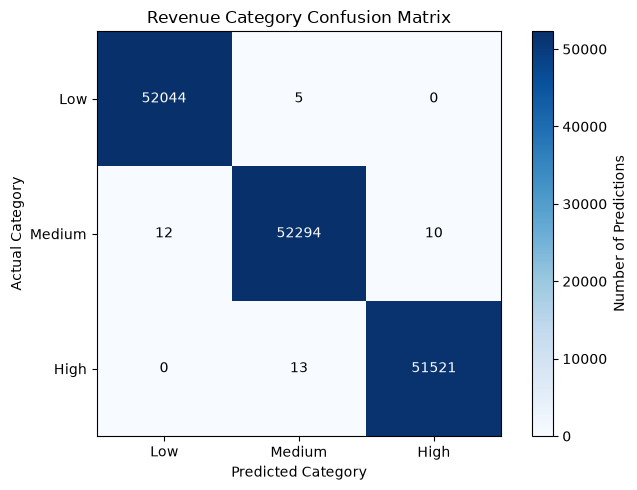

In [20]:
# Random Forest Revenue Category Classification

# Create three revenue categories using revenue quantiles
df["Revenue Category"] = pd.qcut(
    df["Revenue"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

# Select numerical features, excluding the target and original revenue value
features = [
    "Quantity",
    "Price",
    "Year",
    "Month",
    "Day",
    "Hour"
]

X = df[features]
y = df["Revenue Category"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(7, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Revenue Category Confusion Matrix")
plt.colorbar(label="Number of Predictions")

plt.xticks(range(3), ["Low", "Medium", "High"])
plt.yticks(range(3), ["Low", "Medium", "High"])
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        plt.text(
            col,
            row,
            cm[row, col],
            ha="center",
            va="center",
            color="white" if cm[row, col] > cm.max() / 2 else "black"
        )

plt.tight_layout()
plt.show()

# Business Insights

## Key Findings

- Electronics and decorative products generate the highest revenue.
- The United Kingdom contributes the majority of sales.
- High-value customers should receive loyalty rewards.
- At-risk customers need retention campaigns.

## Risks

- Revenue depends heavily on a few customer segments.
- Seasonal fluctuations affect monthly sales.

## Opportunities

- Increase marketing for top-performing products.
- Expand sales in high-growth countries.

# Conclusion

RetailIQ_AI successfully transforms raw retail transaction data into actionable business intelligence through data analytics, visualization, customer segmentation, and machine learning. The project enables data-driven decision making for retail businesses.